В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

[Мій Python модуль](https://github.com/ShishovaInna/ML_studying/blob/main/notebooks/Modul-2/2.2%20%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0%20%D0%BA%D0%BB%D0%B0%D1%81%D0%B8%D1%84%D1%96%D0%BA%D0%B0%D1%86%D1%96%D1%97/process_bank_churn.py)

In [1]:
import pandas as pd
import numpy as np

from process_bank_churn import preprocess_data

df = pd.read_csv("/content/train.csv")
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(df)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [3]:
train_probs = model_knn.predict_proba(X_train)[:, 1]
val_probs = model_knn.predict_proba(X_val)[:, 1]

# Рахуємо ROC AUC
train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9610
Validation ROC AUC: 0.8750


Значення Validation ROC AUC 0,8750 — це хороший результат для базової моделі.  
Але Train ROC AUC 0,9610 і це вказує на можливе перенавчання. У Validation AUC значно нижчий, тож у моделі спостерігається High Variance.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [8]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 35, 2)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33])})

In [9]:
knn_best = knn_gs.best_estimator_
print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(11)} 0.8860833333333333


In [10]:
knn_gs.best_estimator_

KNeighborsClassifier(n_neighbors=np.int64(11))

In [11]:
knn_best = knn_gs.best_estimator_

train_probs = knn_best.predict_proba(X_train)[:, 1]
val_probs = knn_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9469
Validation ROC AUC: 0.9018


розрив між Train та Validation зменьшився, ще й Validation ROC AUC став більше, тож модель значно краща ніж попередня.  
В порівнянні з попереднім ДЗ:
Для Max Depth = 5 найкраще значення ROC AUC:  
Training AUC = 0.925694  
Validation AUC = 0.921927    
І тут дерева рішень виявилися кращими.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [13]:
from sklearn.tree import DecisionTreeClassifier
import time

dtc = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11)
}

model_dtc = GridSearchCV(dtc, param_grid, cv=3, scoring='roc_auc')
start_time = time.time()
model_dtc.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time
print(f"Час пошуку: {execution_time:.2f} секунд")

Час пошуку: 7.19 секунд


In [14]:
model_dtc.best_estimator_

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=np.int64(10),
                       random_state=42)

In [16]:
dt_best = model_dtc.best_estimator_

train_probs = dt_best.predict_proba(X_train)[:, 1]
val_probs = dt_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9015
Validation ROC AUC: 0.9002


Модель з ручного підбору дає кращі результати на валідаціі, але розрив між Train і Validation більший ніж у підборі завдяки GridSearchCV. Проте цей розрив досить маленький і я вважаю що попередня модель, без обмеження max_leaf_nodes була кращою.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [17]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [18]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=dtc,
    param_distributions=params_dt,
    n_iter=40,
    cv=3,
    scoring='roc_auc',
    random_state=42
)

start_time = time.time()
random_search.fit(X_train, y_train)

end_time = time.time()
execution_time = end_time - start_time
print(f"Час пошуку: {execution_time:.2f} секунд")

Час пошуку: 1.12 секунд


In [19]:
random_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=np.int64(16),
                       max_leaf_nodes=np.int64(14), min_samples_leaf=2,
                       min_samples_split=20, random_state=42)

In [20]:
random_search.best_params_

{'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': np.int64(14),
 'max_features': None,
 'max_depth': np.int64(16),
 'criterion': 'entropy'}

In [22]:
dt_random_search_best = random_search.best_estimator_

train_probs = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 0.9169
Validation ROC AUC: 0.9166


Модель з RandomizedSearchCV виявилася кращою за модель з GridSearchCV (0.9166 і 0.9002). Також модель практично ідеально узагальнює дані й не перенавчається.
max_leaf_nodes зросла з 10 до 14.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [24]:
from process_bank_churn import preprocess_new_data

test_df = pd.read_csv("/content/test.csv")
X_test = preprocess_new_data(test_df, input_cols, scaler, encoder)

sample = pd.read_csv("/content/sample_submission.csv")
sample['Exited'] = dt_random_search_best.predict(X_test)

# Зберігаємо готовий файл
sample.to_csv("my_submission_new.csv", index=False)

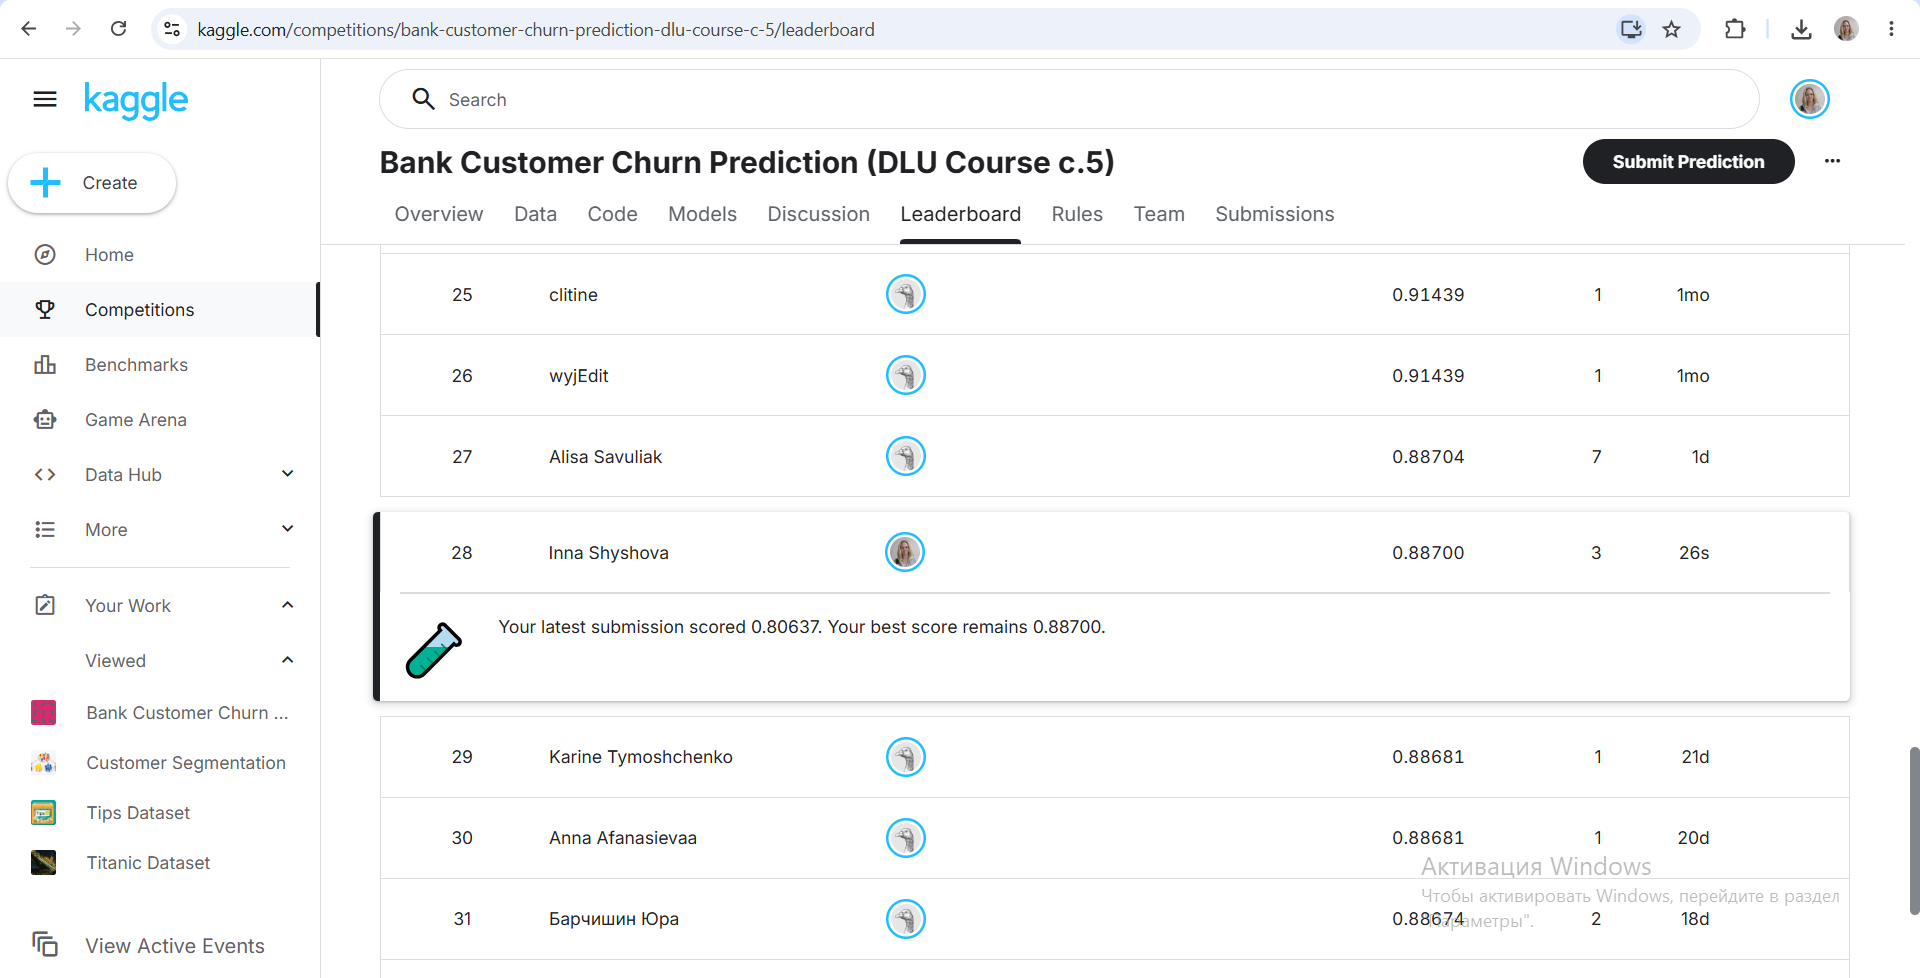